# M4U3 – Road Pavement Defect Detection Using YOLOv8

This notebook trains and evaluates a YOLOv8 object detection model for identifying common road pavement defects from road images.

### Classes
1. pothole
2. road_crack
3. uneven_manhole

### Objective
The objective is to develop a computer vision prototype that can support road inspection by automatically identifying visible pavement defects from images.

The model is intended as an assistive screening tool. Detected defects should be verified by qualified personnel before maintenance or safety decisions are made.

### Workflow
Dataset → YOLOv8 Training → Validation → Performance Evaluation → Trained Model

In [1]:
!pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.7/46.7 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 39.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 11.3 MB/s eta 0:00:00


## 3. Dataset Access

The exact dataset version used for this experiment is stored as a frozen ZIP file in the project's GitHub Release (v1.0).

Version 1 contains 252 source images. After preprocessing and augmentation, the exported dataset contains 656 images: 606 training images and 50 validation images.

The dataset is downloaded directly from the GitHub Release without requiring a Roboflow account or API key. A SHA256 checksum is used to verify that the downloaded file is identical to the frozen dataset version used for this experiment.

Roboflow Universe is retained as the annotation and dataset-versioning reference.

In [2]:
import hashlib
import zipfile
import urllib.request
import yaml
from pathlib import Path

# Frozen dataset used for this experiment
DATA_URL = "https://github.com/prathish-lab/M4U3-Road-Pavement-Defect-Detection/releases/download/v1.0/road_dataset.zip"

SHA256 = "08baedc06678983e6f431741b8b859c4a26eb821135ea6f22ea0bbe09dc6c858"

ROOT = Path("/content/dataset")
ZIP_PATH = Path("/content/dataset.zip")


def sha256_file(path, chunk=1 << 20):
    h = hashlib.sha256()
    with open(path, "rb") as f:
        for block in iter(lambda: f.read(chunk), b""):
            h.update(block)
    return h.hexdigest()


def find_data_yaml(root: Path) -> Path:
    hits = list(root.rglob("data.yaml"))
    if not hits:
        raise FileNotFoundError(f"No data.yaml found under {root}")
    return hits[0]


# Download the frozen dataset if it is not already available
already_ready = (ROOT / "data.yaml").exists() or any(ROOT.glob("*/data.yaml"))

if not already_ready:
    ROOT.mkdir(parents=True, exist_ok=True)

    if ZIP_PATH.exists():
        ZIP_PATH.unlink()

    print("Downloading frozen dataset...")
    urllib.request.urlretrieve(DATA_URL, ZIP_PATH)

    print("Verifying SHA256 checksum...")
    digest = sha256_file(ZIP_PATH)

    if digest != SHA256:
        ZIP_PATH.unlink(missing_ok=True)
        raise AssertionError(f"Checksum mismatch: {digest}")

    print("Checksum verified successfully.")

    with zipfile.ZipFile(ZIP_PATH) as z:
        z.extractall(ROOT)


# Locate and configure data.yaml
cfg_path = find_data_yaml(ROOT)
dataset_root = cfg_path.parent

cfg = yaml.safe_load(cfg_path.read_text())

cfg["path"] = str(dataset_root)
cfg["train"] = "train/images"
cfg["val"] = "valid/images"

if (dataset_root / "test" / "images").is_dir():
    cfg["test"] = "test/images"
else:
    cfg.pop("test", None)

cfg_path.write_text(yaml.safe_dump(cfg, sort_keys=False))

print("\nDataset ready.")
print("Configuration:", cfg_path)
print(cfg)

Verifying SHA256 checksum...
Checksum verified successfully.

Dataset ready.
Configuration: /content/dataset/data.yaml
{'train': 'train/images', 'val': 'valid/images', 'nc': 3, 'names': ['pothole', 'road_crack', 'uneven_manhole'], 'roboflow': {'workspace': 'psprathish-gmail-com', 'project': 'road-pavement-defect-dataset', 'version': 1, 'license': 'Private', 'url': 'https://app.roboflow.com/psprathish-gmail-com/road-pavement-defect-dataset/1'}, 'path': '/content/dataset'}


## 4. Dataset Sanity Check

The frozen dataset downloaded from the GitHub Release is checked before training to confirm the dataset structure, configuration file, class definitions, and number of images in each split.

In [3]:
import os

print("Dataset location:", dataset_root)

print("\nTraining images:",
      len(os.listdir(dataset_root / "train/images")))

print("Validation images:",
      len(os.listdir(dataset_root / "valid/images")))

print("\nDataset configuration:")
with open(cfg_path, "r") as file:
    print(file.read())

Dataset location: /content/dataset

Training images: 606
Validation images: 50

Dataset configuration:
train: train/images
val: valid/images
nc: 3
names:
- pothole
- road_crack
- uneven_manhole
roboflow:
  workspace: psprathish-gmail-com
  project: road-pavement-defect-dataset
  version: 1
  license: Private
  url: https://app.roboflow.com/psprathish-gmail-com/road-pavement-defect-dataset/1
path: /content/dataset



## 5. YOLOv8 Model Setup

A pretrained YOLOv8 Nano (yolov8n.pt) model is used as the starting point for transfer learning. The model is fine-tuned on the road pavement defect dataset containing three classes.

In [4]:
from ultralytics import YOLO

# Load the pretrained YOLOv8 Nano model
model = YOLO("yolov8n.pt")

print("Pretrained model loaded successfully.")

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
Pretrained model loaded successfully.


## 6. Model Training

The YOLOv8 Nano model is trained for 30 epochs using an image size of 640 × 640 pixels and a batch size of 16.

In [5]:
train_results = model.train(
    data=str(cfg_path),
    epochs=30,
    imgsz=640,
    batch=16,
    device=0,
    project="/content/runs",
    name="M4U3_road_defects"
)

Ultralytics 8.4.160 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=M4U3_road_defects, nbs=64, nms=None, opset=None, 

## 7. Model Validation

The best-performing model weights generated during training are loaded and evaluated on the validation dataset. Precision, recall, mAP@50, and mAP@50–95 are used to assess detection performance.

In [6]:
# Load the best trained model
best_model = YOLO("/content/runs/M4U3_road_defects/weights/best.pt")

# Evaluate on the validation set
metrics = best_model.val(
    data=str(cfg_path)
)

Ultralytics 8.4.160 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 72 layers, 3,006,233 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1953.3±360.5 MB/s, size: 78.8 KB)
val: Scanning /content/dataset/valid/labels.cache... 50 images, 1 backgrounds, 9 corrupt: 100% ━━━━━━━━━━━━ 50/50 15.0Mit/s 0.0s
val: /content/dataset/valid/images/1061_jpg.rf.11d3ad835f93f2de0f048b50c9189817.jpg: ignoring corrupt image/label: labels mix segment and detection rows
val: /content/dataset/valid/images/156_jpg.rf.6b44e2fa518e56d237e087c709a38cac.jpg: ignoring corrupt image/label: labels mix segment and detection rows
val: /content/dataset/valid/images/20250219_164838_jpg.rf.2fdb0e7b229d38c24e2bc1739a342123.jpg: ignoring corrupt image/label: labels mix segment and detection rows
val: /content/dataset/valid/images/281_jpg.rf.bf7fb3917dd59fc75e0fe86546f9bfed.jpg: ignoring corrupt image/label: labels mix segment and detection rows
va

## 8. Training Performance

The following plots show the training and validation losses together with precision, recall, mAP@50, and mAP@50–95 across the 30 training epochs.

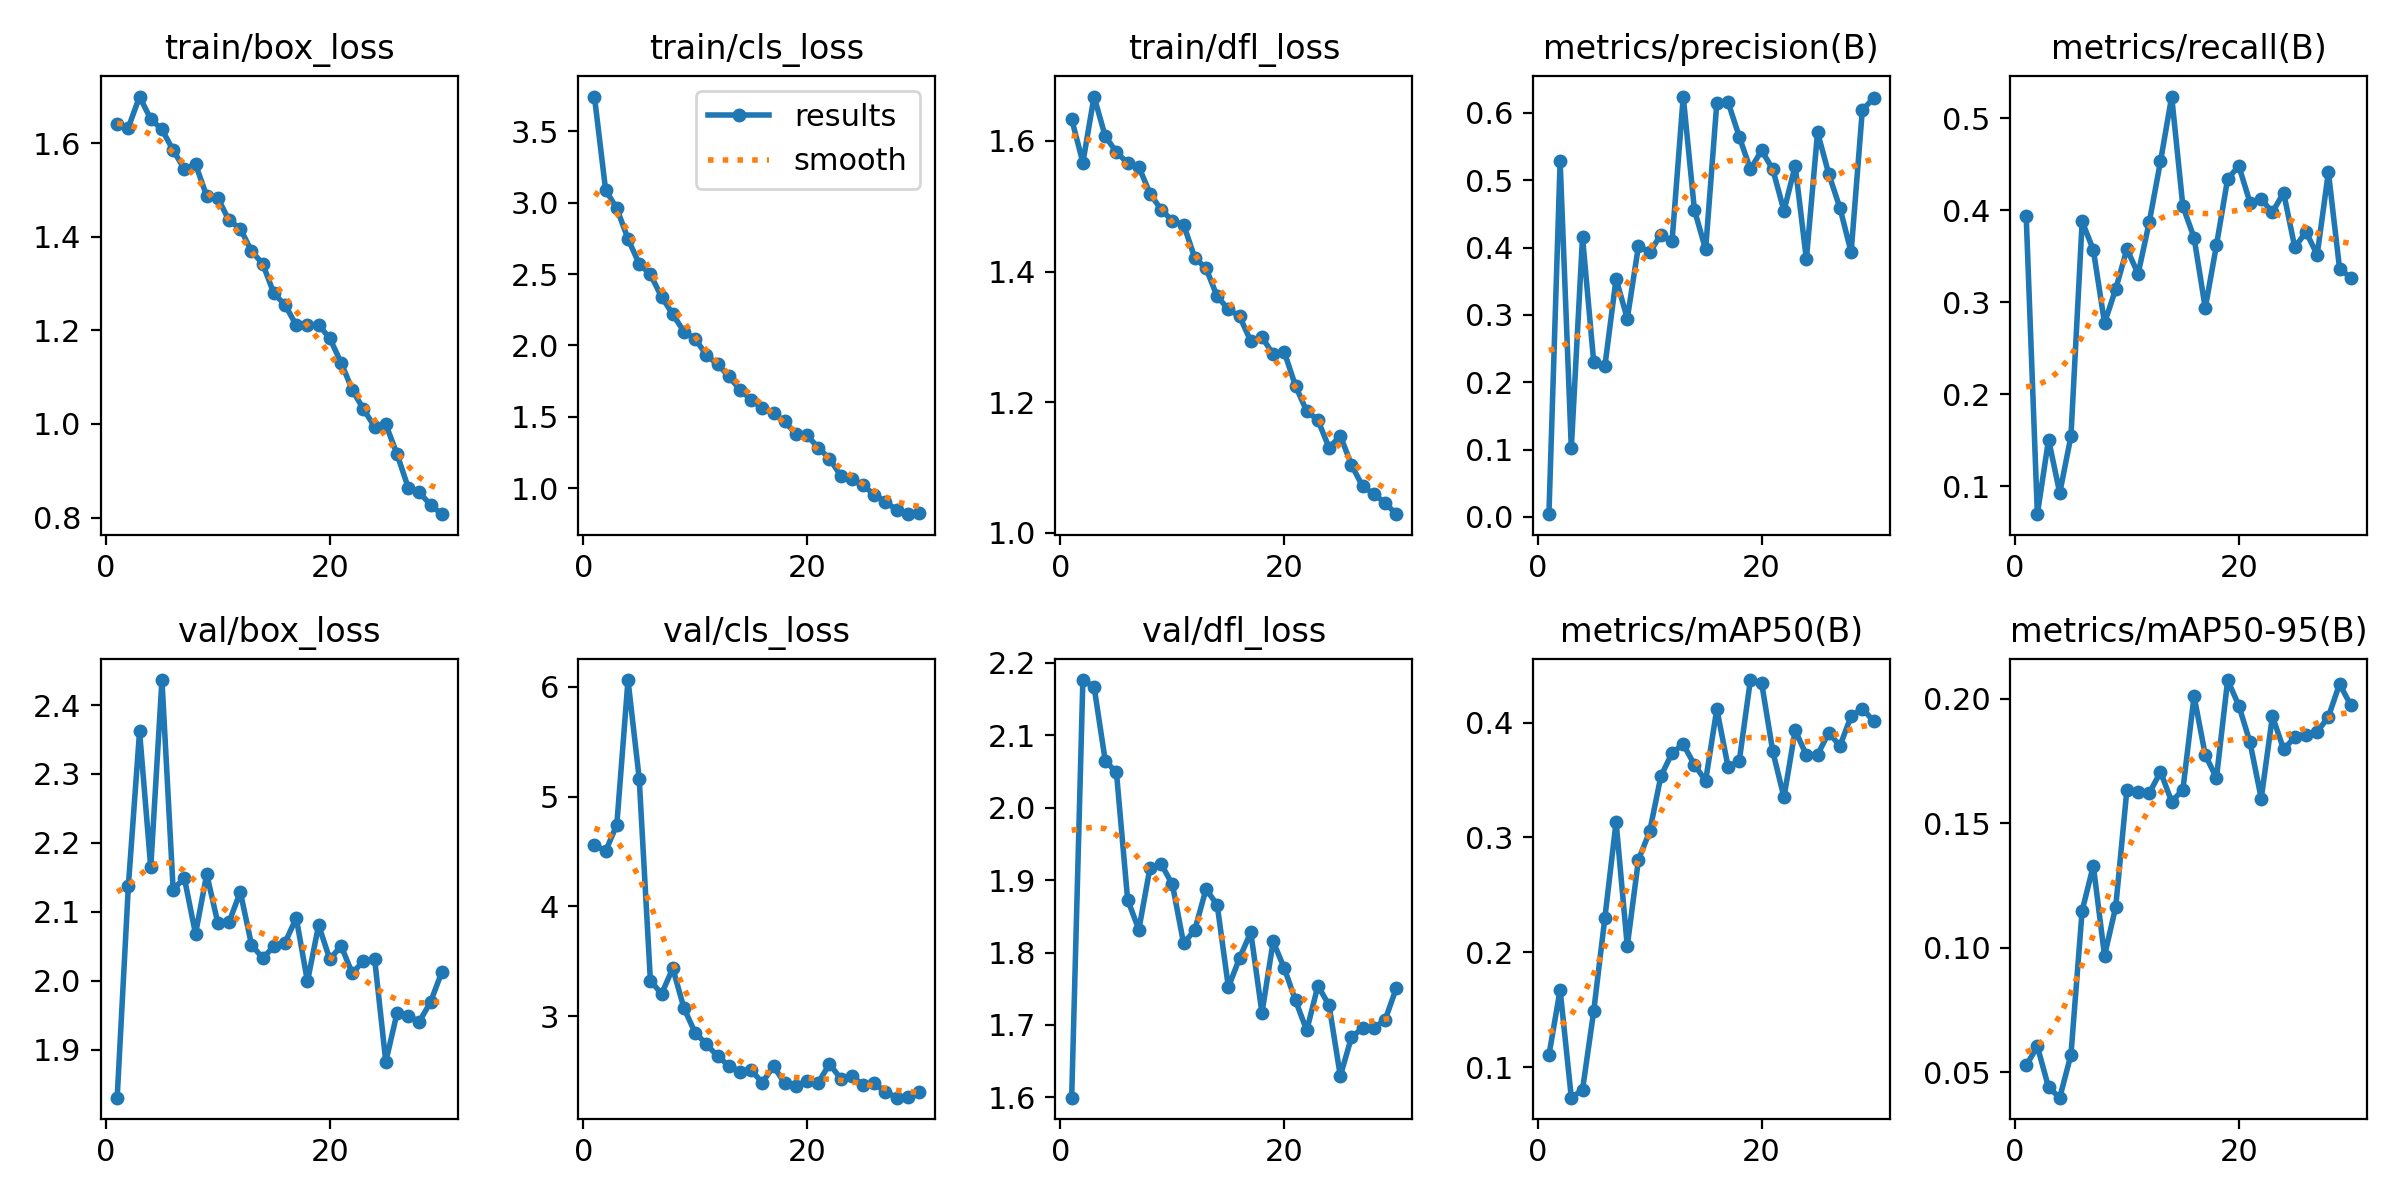

In [7]:
from IPython.display import Image, display

results_path = "/content/runs/M4U3_road_defects/results.png"

display(Image(filename=results_path))

## 9. Confusion Matrix

The normalized confusion matrix is used to examine class-level detection performance and identify where the model correctly detects, confuses, or misses pavement defects. The background row and column represent unmatched ground-truth objects and unmatched predictions respectively.

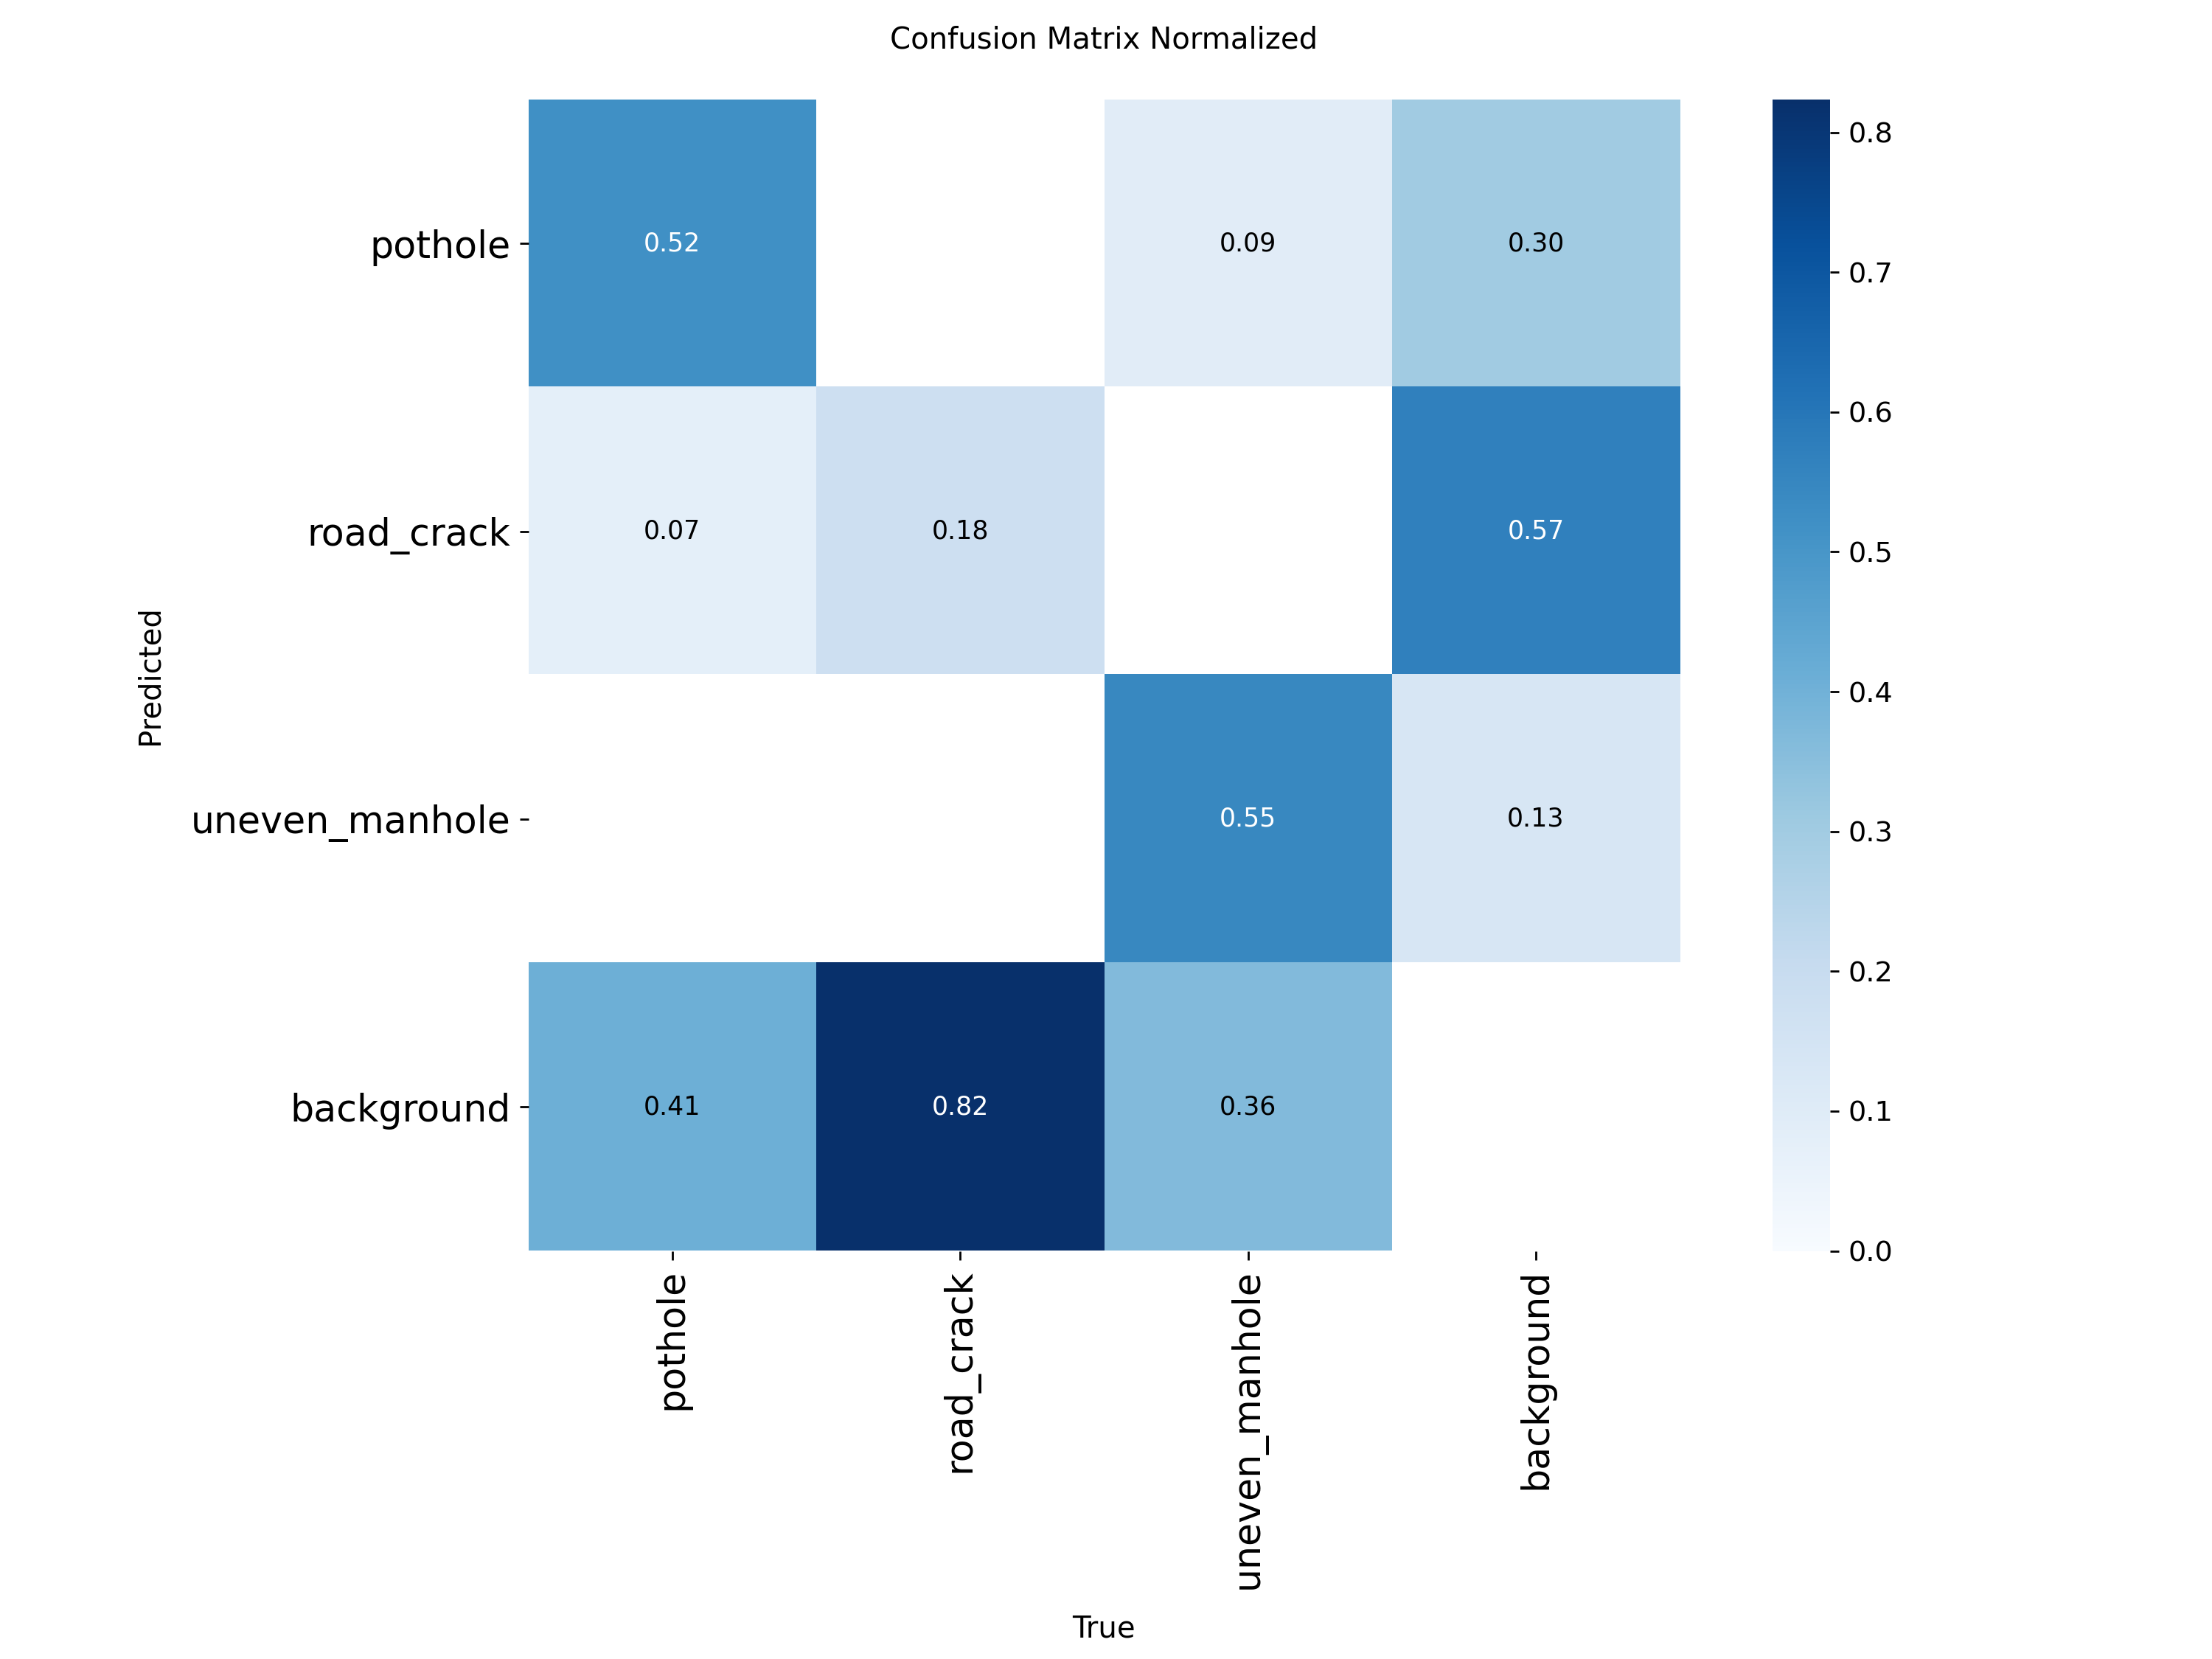

In [8]:
confusion_matrix_path = "/content/runs/M4U3_road_defects/confusion_matrix_normalized.png"

display(Image(filename=confusion_matrix_path))

## 10. Trained Model Classes

The trained model is checked to confirm that it contains the three road pavement defect classes defined for this project.

In [9]:
# Check the classes stored in the trained model
print(best_model.names)
print("Number of classes:", len(best_model.names))

{0: 'pothole', 1: 'road_crack', 2: 'uneven_manhole'}
Number of classes: 3


## 11. Trained Model Weights

YOLOv8 automatically saves the best-performing model weights during training. The *best.pt* file is retained for validation and inference on unseen road images.

In [10]:
import os

best_weights = "/content/runs/M4U3_road_defects/weights/best.pt"

if os.path.exists(best_weights):
    print("best.pt found successfully.")
    print("Location:", best_weights)
    print("File size:", round(os.path.getsize(best_weights) / (1024**2), 2), "MB")
else:
    print("best.pt not found.")

best.pt found successfully.
Location: /content/runs/M4U3_road_defects/weights/best.pt
File size: 5.96 MB


## 12. Reproducibility Summary

This notebook provides the complete cloud-based training and validation workflow for the road pavement defect detection model.

### Model Configuration
- Model: YOLOv8 Nano (yolov8n.pt)
- Task: Object Detection
- Classes: pothole, road_crack, uneven_manhole
- Source dataset: 252 images
- Exported dataset: 656 images
  - Training: 606 images
  - Validation: 50 images
- Image size: 640 × 640
- Epochs: 30
- Batch size: 16
- Training environment: Google Colab with NVIDIA T4 GPU

### Dataset Reproducibility
The exact dataset used for this experiment is stored as a frozen ZIP file in the project's GitHub Release (v1.0). The notebook downloads the dataset without requiring a Roboflow account, API key, or Colab Secret.

Dataset integrity is verified using a SHA256 checksum before extraction. Roboflow Universe Version 1 is retained as the dataset annotation and versioning reference.

### Validation Results

The reproduced validation achieved a precision of 0.511, recall of 0.434, mAP@50 of 0.438, and mAP@50–95 of 0.207.

Class-level results indicate that *uneven_manhole* achieved the strongest detection performance, while *road_crack* remained the most challenging class.

Class-level evaluation showed stronger performance for pothole and uneven_manhole, while *road_crack* remained the most challenging class.

### Intended Use
The trained best.pt model is used in the separate inference notebook to evaluate previously unseen road photographs.

This model is an educational prototype intended to support road-condition screening. Model detections should be verified by qualified personnel before maintenance or safety decisions are made.